In [1]:
import pandas as pd
df = pd.read_csv('iris.csv')
print(df.shape)



(150, 5)


In [5]:
import pandas as pd
df = pd.read_csv('iris.csv')
pd.set_option('display.max_columns', None)
df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [6]:
import pandas as pd
df = pd.read_csv('iris.csv')
print(df.dtypes)


sepal.length    float64
sepal.width     float64
petal.length    float64
petal.width     float64
variety          object
dtype: object


In [7]:
import pandas as pd
df = pd.read_csv('iris.csv')
print(df.isnull().values.any())



False


In [8]:
import pandas as pd
df = pd.read_csv('iris.csv')
print(df.duplicated().sum())



1


In [ ]:
import pandas as pd
df = pd.read_csv('iris.csv')
print(df.duplicated().sum())

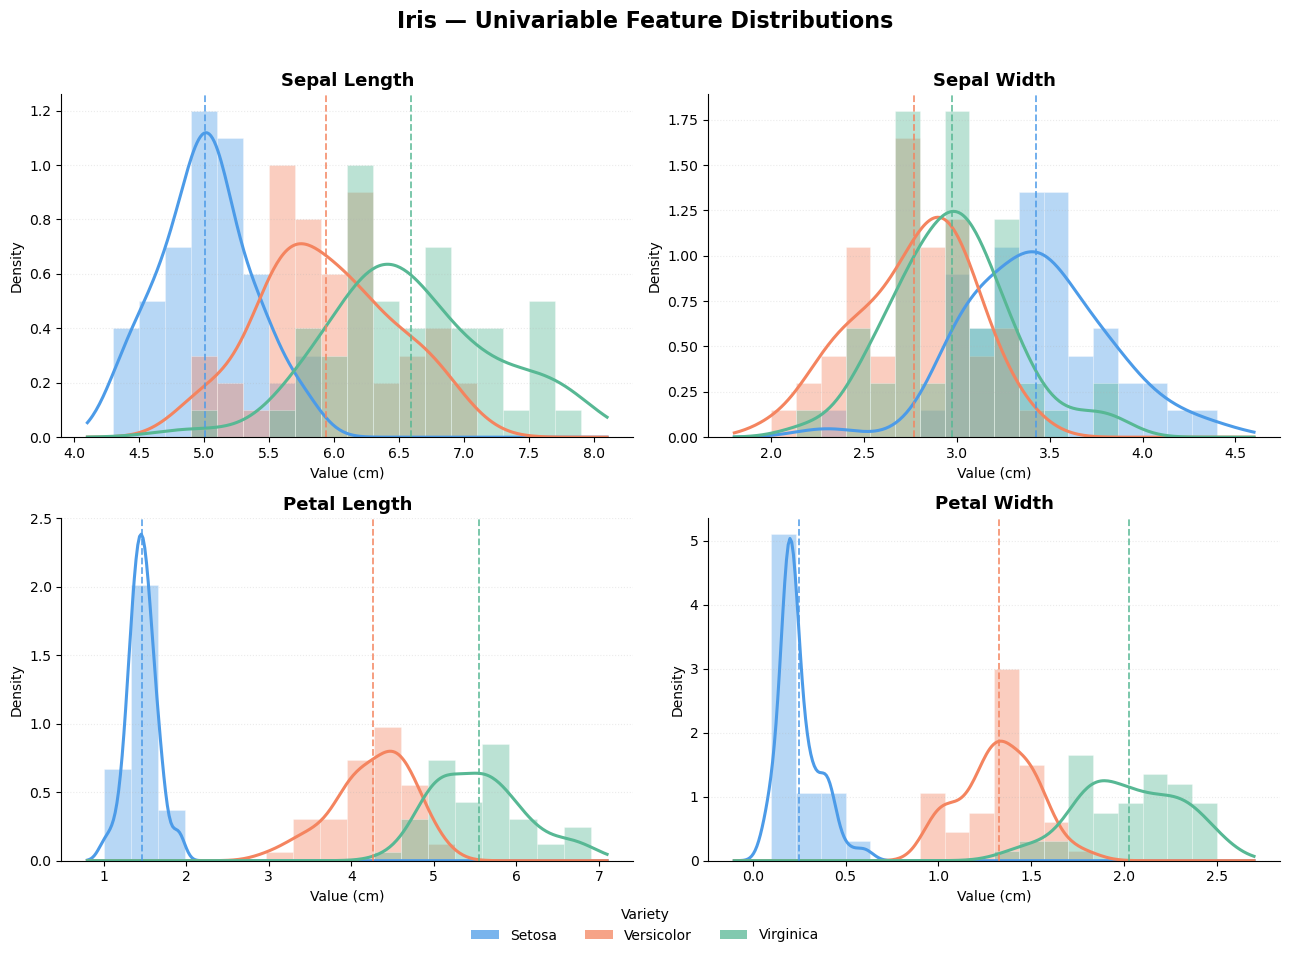

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import gaussian_kde

df = pd.read_csv('iris.csv')

features = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']
varieties = df['variety'].unique()

COLORS = {
    'Setosa':     '#4C9BE8',
    'Versicolor': '#F4845F',
    'Virginica':  '#57B894',
}

BINS = 18
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Iris — Univariable Feature Distributions', fontsize=16, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flat, features):
    global_min = df[feat].min()
    global_max = df[feat].max()
    bin_edges = np.linspace(global_min, global_max, BINS + 1)

    for variety in varieties:
        data = df.loc[df['variety'] == variety, feat].dropna().values
        color = COLORS.get(variety, 'gray')

        ax.hist(data, bins=bin_edges, density=True, alpha=0.40,
                color=color, edgecolor='white', linewidth=0.5)

        if len(data) > 1:
            kde = gaussian_kde(data, bw_method='scott')
            x_range = np.linspace(global_min - 0.2, global_max + 0.2, 300)
            ax.plot(x_range, kde(x_range), color=color, linewidth=2.2)

    for variety in varieties:
        mean_val = df.loc[df['variety'] == variety, feat].mean()
        ax.axvline(mean_val, color=COLORS.get(variety, 'gray'),
                   linestyle='--', linewidth=1.3, alpha=0.85)

    ax.set_title(feat.replace('.', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Value (cm)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25, linestyle=':')

legend_handles = [mpatches.Patch(facecolor=COLORS[v], alpha=0.75, label=v) for v in varieties]
fig.legend(handles=legend_handles, title='Variety', title_fontsize=10,
           fontsize=10, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.04), frameon=False)

plt.tight_layout()
plt.show()

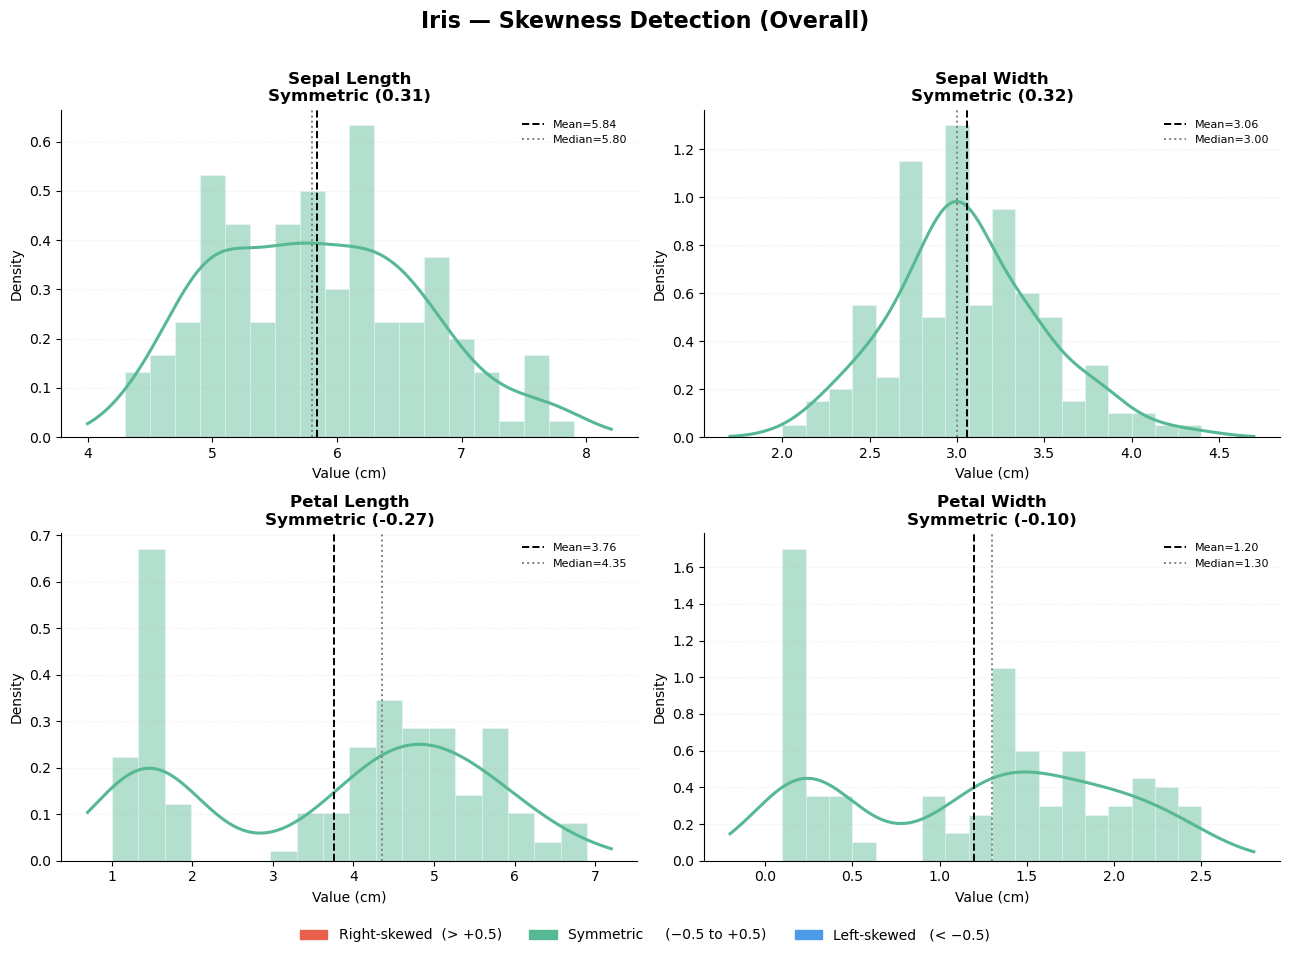


Skewness Summary:
-----------------------------------
  sepal.length         +0.3118  →  Symmetric (0.31)
  sepal.width          +0.3158  →  Symmetric (0.32)
  petal.length         -0.2721  →  Symmetric (-0.27)
  petal.width          -0.1019  →  Symmetric (-0.10)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import skew

df = pd.read_csv('iris.csv')

features = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']

def skew_label(s):
    if s > 0.5:
        return f'Right-skewed ({s:.2f})'
    elif s < -0.5:
        return f'Left-skewed ({s:.2f})'
    else:
        return f'Symmetric ({s:.2f})'

def skew_color(s):
    if s > 0.5:
        return '#E8604C'   # red → right skew
    elif s < -0.5:
        return '#4C9BE8'   # blue → left skew
    else:
        return '#57B894'   # green → symmetric

BINS = 18
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Iris — Skewness Detection (Overall)', fontsize=16, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flat, features):
    data = df[feat].dropna().values
    s = skew(data)
    color = skew_color(s)

    bin_edges = np.linspace(data.min(), data.max(), BINS + 1)
    ax.hist(data, bins=bin_edges, density=True, alpha=0.45,
            color=color, edgecolor='white', linewidth=0.5)

    
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data, bw_method='scott')
    x_range = np.linspace(data.min() - 0.3, data.max() + 0.3, 300)
    ax.plot(x_range, kde(x_range), color=color, linewidth=2.2)

    # Mean and median lines
    ax.axvline(np.mean(data), color='black', linestyle='--', linewidth=1.4, label=f'Mean={np.mean(data):.2f}')
    ax.axvline(np.median(data), color='gray', linestyle=':', linewidth=1.4, label=f'Median={np.median(data):.2f}')

    ax.set_title(f"{feat.replace('.', ' ').title()}\n{skew_label(s)}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Value (cm)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25, linestyle=':')
    ax.legend(fontsize=8, frameon=False)


legend_handles = [
    mpatches.Patch(color='#E8604C', label='Right-skewed  (> +0.5)'),
    mpatches.Patch(color='#57B894', label='Symmetric     (−0.5 to +0.5)'),
    mpatches.Patch(color='#4C9BE8', label='Left-skewed   (< −0.5)'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.04), fontsize=10, frameon=False)

plt.tight_layout()
plt.show()


print("\nSkewness Summary:")
print("-" * 35)
for feat in features:
    s = skew(df[feat].dropna())
    print(f"  {feat:<20} {s:+.4f}  →  {skew_label(s)}")

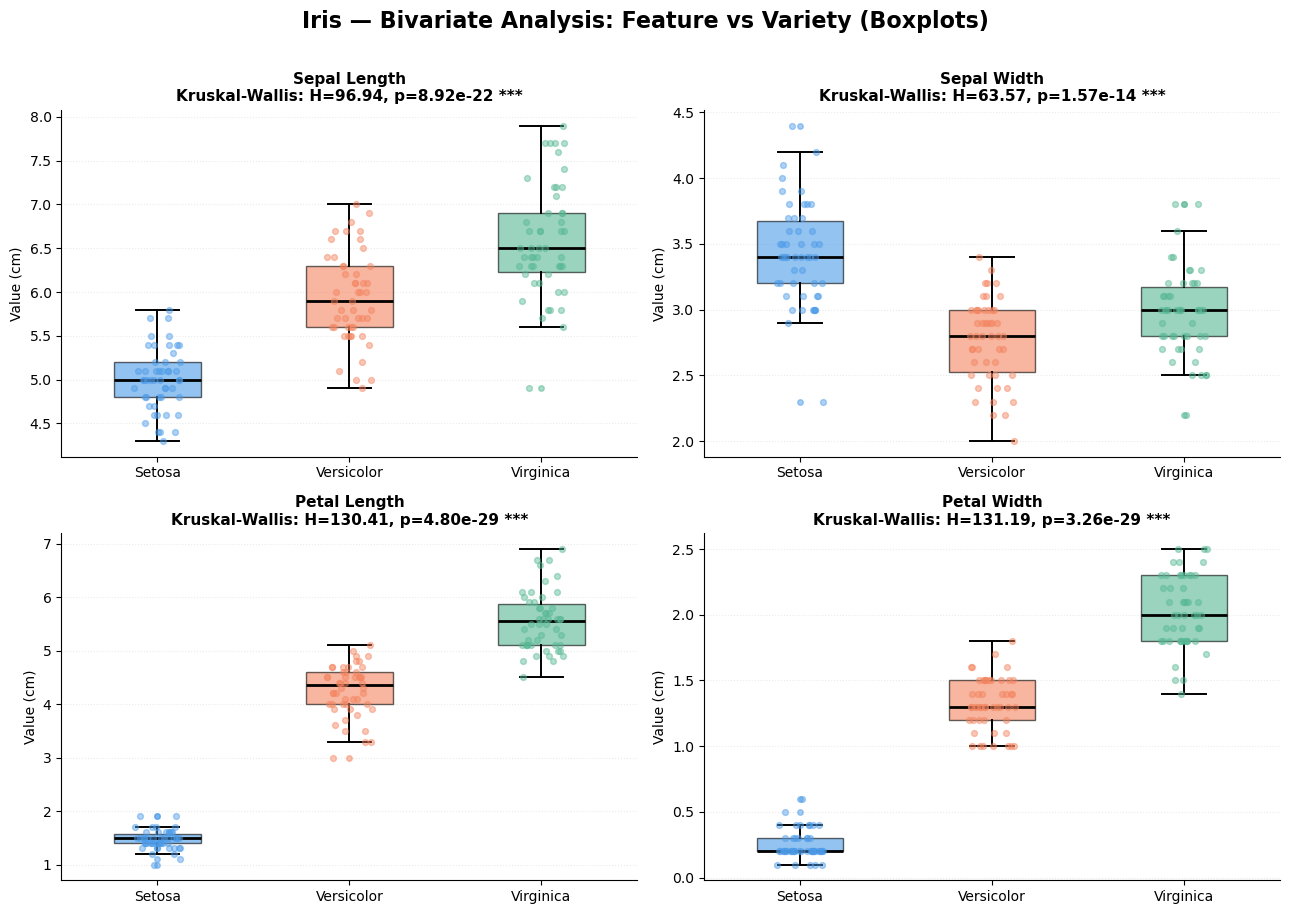


Group Means:
            sepal.length  sepal.width  petal.length  petal.width
variety                                                         
Setosa             5.006        3.428         1.462        0.246
Versicolor         5.936        2.770         4.260        1.326
Virginica          6.588        2.974         5.552        2.026


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kruskal

df = pd.read_csv('iris.csv')

features = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']
varieties = df['variety'].unique()

COLORS = {
    'Setosa':     '#4C9BE8',
    'Versicolor': '#F4845F',
    'Virginica':  '#57B894',
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Iris — Bivariate Analysis: Feature vs Variety (Boxplots)',
             fontsize=16, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flat, features):
    groups = [df.loc[df['variety'] == v, feat].dropna().values for v in varieties]

    bp = ax.boxplot(
        groups,
        patch_artist=True,
        widths=0.45,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.4),
        capprops=dict(linewidth=1.4),
        flierprops=dict(marker='o', markersize=4, alpha=0.5, linestyle='none')
    )

    for patch, variety in zip(bp['boxes'], varieties):
        patch.set_facecolor(COLORS[variety])
        patch.set_alpha(0.6)

    for flier, variety in zip(bp['fliers'], varieties):
        flier.set_markerfacecolor(COLORS[variety])
        flier.set_markeredgecolor(COLORS[variety])

    # Jittered strip overlay
    for i, (variety, group) in enumerate(zip(varieties, groups), start=1):
        jitter = np.random.uniform(-0.12, 0.12, size=len(group))
        ax.scatter(i + jitter, group, color=COLORS[variety],
                   alpha=0.45, s=18, zorder=3)

    # Kruskal-Wallis test
    stat, p = kruskal(*groups)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_title(f"{feat.replace('.', ' ').title()}\nKruskal-Wallis: H={stat:.2f}, p={p:.2e} {sig}",
                 fontsize=11, fontweight='bold')

    ax.set_xticks(range(1, len(varieties) + 1))
    ax.set_xticklabels(varieties, fontsize=10)
    ax.set_ylabel('Value (cm)', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25, linestyle=':')

plt.tight_layout()
plt.show()

# Group means table
print("\nGroup Means:")
print(df.groupby('variety')[features].mean().round(3).to_string())

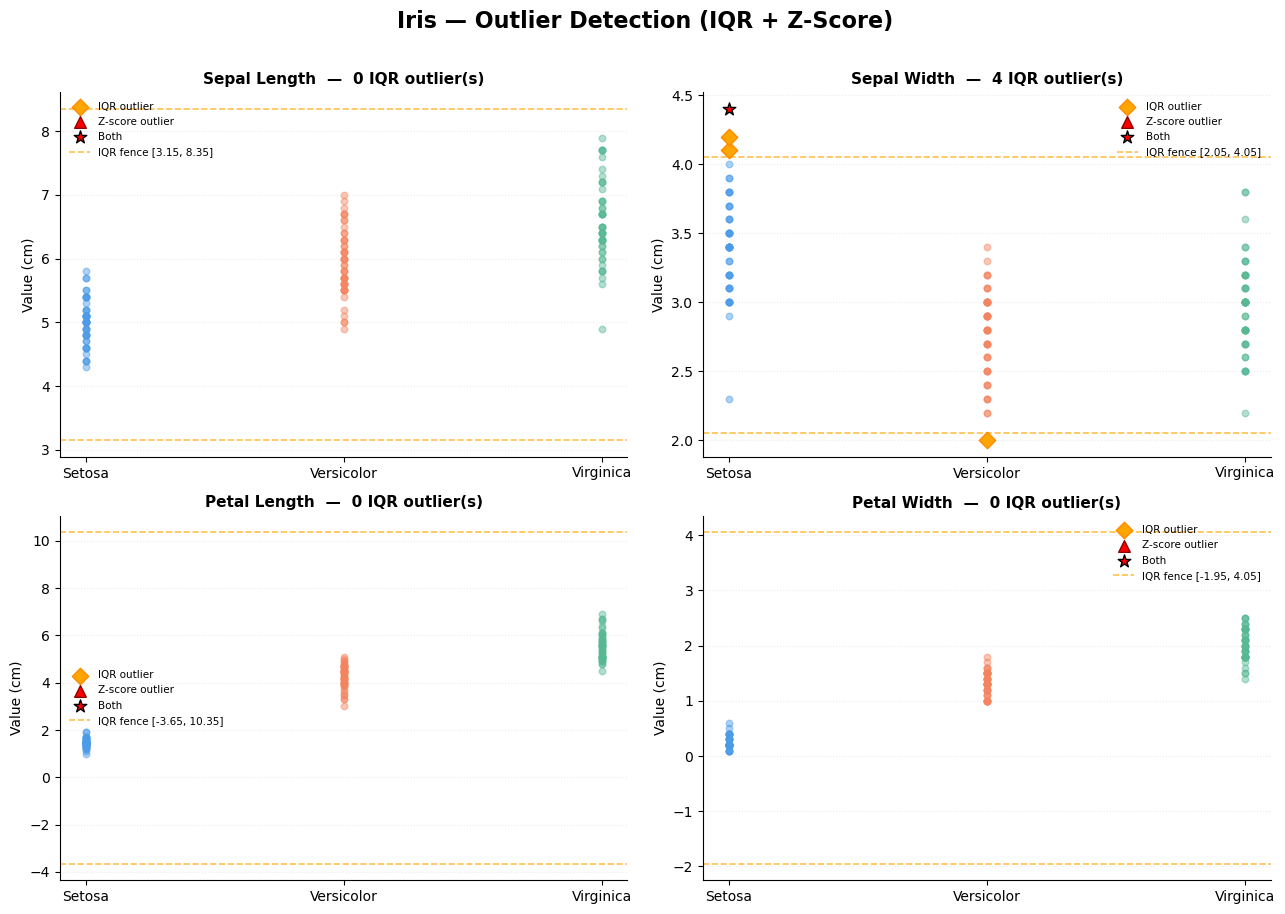


Outlier Summary (IQR method):
---------------------------------------------
  sepal.length         0 outlier(s)  →  rows []
  sepal.width          4 outlier(s)  →  rows [15, 32, 33, 60]
  petal.length         0 outlier(s)  →  rows []
  petal.width          0 outlier(s)  →  rows []

Outlier Summary (Z-score |z| > 3):
---------------------------------------------
  sepal.length         0 outlier(s)  →  rows []
  sepal.width          1 outlier(s)  →  rows [15]
  petal.length         0 outlier(s)  →  rows []
  petal.width          0 outlier(s)  →  rows []


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

df = pd.read_csv('iris.csv')

features = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']

COLORS = {
    'Setosa':     '#4C9BE8',
    'Versicolor': '#F4845F',
    'Virginica':  '#57B894',
}

# --- Outlier flags ---
# IQR method
def iqr_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)

df['z_outlier']   = False
df['iqr_outlier'] = False

for feat in features:
    df['z_outlier']   |= zscore(df[feat]).abs() > 3
    df['iqr_outlier'] |= iqr_outliers(df[feat])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Iris — Outlier Detection (IQR + Z-Score)',
             fontsize=16, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flat, features):
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    is_iqr_out = iqr_outliers(df[feat])
    is_z_out   = zscore(df[feat]).abs() > 3
    is_both    = is_iqr_out & is_z_out

    varieties = df['variety'].unique()

    # Normal points per variety
    for variety in varieties:
        mask = (df['variety'] == variety) & ~is_iqr_out & ~is_z_out
        ax.scatter(
            df.loc[mask, 'variety'].map({v: i for i, v in enumerate(varieties)}),
            df.loc[mask, feat],
            color=COLORS[variety], alpha=0.45, s=22, zorder=2
        )

    # IQR-only outliers
    mask = is_iqr_out & ~is_z_out
    ax.scatter(
        df.loc[mask, 'variety'].map({v: i for i, v in enumerate(varieties)}),
        df.loc[mask, feat],
        color='orange', edgecolors='darkorange', s=70,
        marker='D', zorder=4, label='IQR outlier'
    )

    # Z-score-only outliers
    mask = is_z_out & ~is_iqr_out
    ax.scatter(
        df.loc[mask, 'variety'].map({v: i for i, v in enumerate(varieties)}),
        df.loc[mask, feat],
        color='red', edgecolors='darkred', s=70,
        marker='^', zorder=4, label='Z-score outlier'
    )

    # Both
    mask = is_both
    ax.scatter(
        df.loc[mask, 'variety'].map({v: i for i, v in enumerate(varieties)}),
        df.loc[mask, feat],
        color='red', edgecolors='black', s=90,
        marker='*', zorder=5, label='Both'
    )

    # IQR fence lines
    ax.axhline(lower, color='orange', linestyle='--', linewidth=1.2, alpha=0.7, label=f'IQR fence [{lower:.2f}, {upper:.2f}]')
    ax.axhline(upper, color='orange', linestyle='--', linewidth=1.2, alpha=0.7)

    n_out = int(is_iqr_out.sum())
    ax.set_title(f"{feat.replace('.', ' ').title()}  —  {n_out} IQR outlier(s)",
                 fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(varieties)))
    ax.set_xticklabels(varieties, fontsize=10)
    ax.set_ylabel('Value (cm)', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.25, linestyle=':')
    ax.legend(fontsize=7.5, frameon=False)

plt.tight_layout()
plt.show()

# --- Summary table ---
print("\nOutlier Summary (IQR method):")
print("-" * 45)
for feat in features:
    out_idx = df[iqr_outliers(df[feat])].index.tolist()
    print(f"  {feat:<20} {len(out_idx)} outlier(s)  →  rows {out_idx}")

print("\nOutlier Summary (Z-score |z| > 3):")
print("-" * 45)
for feat in features:
    out_idx = df[zscore(df[feat]).abs() > 3].index.tolist()
    print(f"  {feat:<20} {len(out_idx)} outlier(s)  →  rows {out_idx}")
    

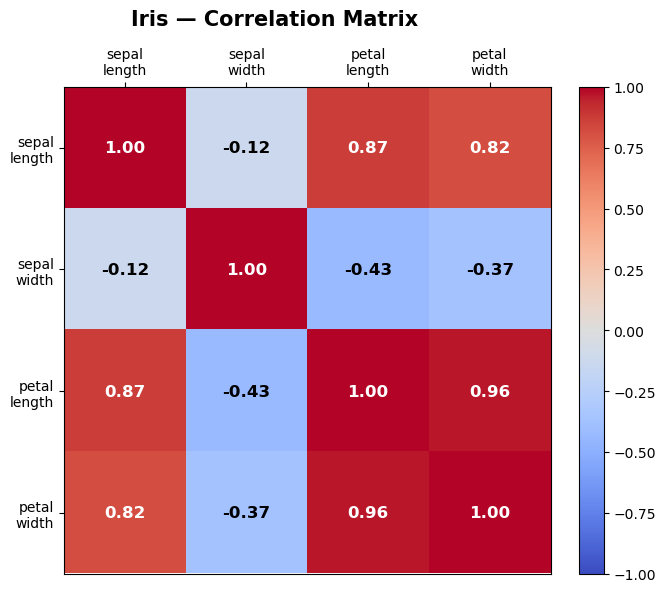

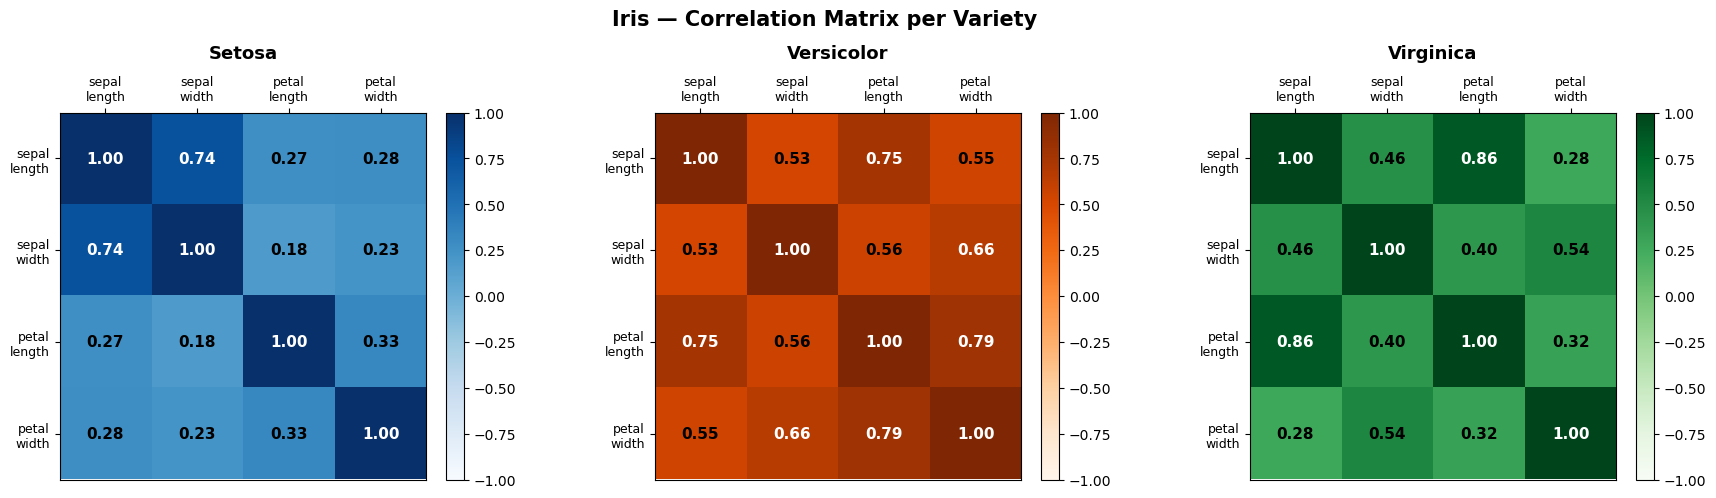

Overall Correlation Matrix:
              sepal.length  sepal.width  petal.length  petal.width
sepal.length          1.00        -0.12          0.87         0.82
sepal.width          -0.12         1.00         -0.43        -0.37
petal.length          0.87        -0.43          1.00         0.96
petal.width           0.82        -0.37          0.96         1.00

Strong correlations (|r| > 0.7):
----------------------------------------
  sepal.length  ↔  petal.length:  r = 0.87  (positive)
  sepal.length  ↔  petal.width:  r = 0.82  (positive)
  petal.length  ↔  petal.width:  r = 0.96  (positive)


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('iris.csv')

features = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']
corr = df[features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Iris — Correlation Matrix', fontsize=15, fontweight='bold')

cax = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)

# Annotations
for i in range(len(features)):
    for j in range(len(features)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=12, fontweight='bold', color=color)

labels = [f.replace('.', '\n') for f in features]
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticklabels(labels, fontsize=10)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

plt.tight_layout()
plt.show()

# --- Per-variety correlation matrices ---
varieties = df['variety'].unique()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Iris — Correlation Matrix per Variety', fontsize=15, fontweight='bold')

CMAPS = {'Setosa': 'Blues', 'Versicolor': 'Oranges', 'Virginica': 'Greens'}

for ax, variety in zip(axes, varieties):
    corr_v = df.loc[df['variety'] == variety, features].corr()
    cax = ax.imshow(corr_v, cmap=CMAPS.get(variety, 'coolwarm'), vmin=-1, vmax=1)
    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)

    for i in range(len(features)):
        for j in range(len(features)):
            val = corr_v.iloc[i, j]
            color = 'white' if abs(val) > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=color)

    ax.set_title(variety, fontsize=13, fontweight='bold', pad=12)
    ax.set_xticks(range(len(features)))
    ax.set_yticks(range(len(features)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

plt.tight_layout()
plt.show()

# --- Summary ---
print("Overall Correlation Matrix:")
print(corr.round(2).to_string())

print("\nStrong correlations (|r| > 0.7):")
print("-" * 40)
for i in range(len(features)):
    for j in range(i + 1, len(features)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            direction = 'positive' if r > 0 else 'negative'
            print(f"  {features[i]}  ↔  {features[j]}:  r = {r:.2f}  ({direction})")

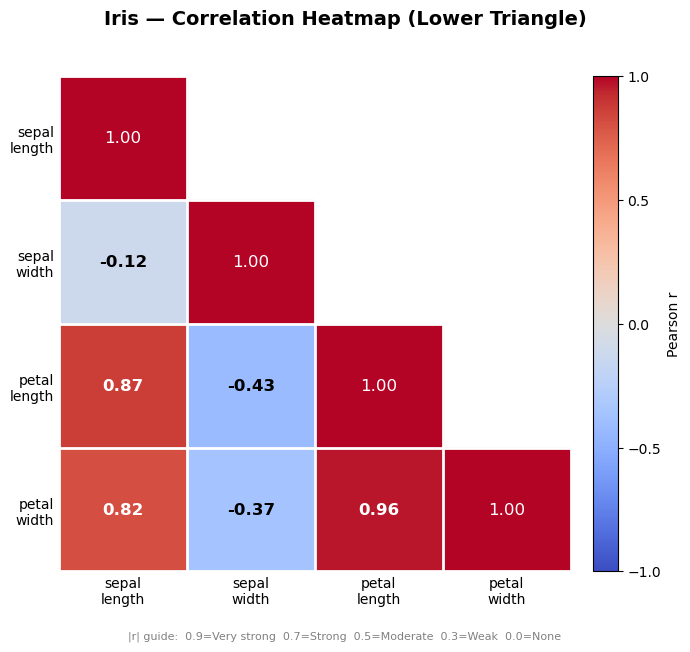


Correlation Interpretation:
--------------------------------------------------
  sepal.length  ↔  sepal.width          r = -0.12  (negligible negative)
  sepal.length  ↔  petal.length         r = +0.87  (strong positive)
  sepal.length  ↔  petal.width          r = +0.82  (strong positive)
  sepal.width  ↔  petal.length         r = -0.43  (weak negative)
  sepal.width  ↔  petal.width          r = -0.37  (weak negative)
  petal.length  ↔  petal.width          r = +0.96  (very strong positive)


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

df = pd.read_csv('iris.csv')

features = ['sepal.length', 'sepal.width', 'petal.length', 'petal.width']
corr = df[features].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_masked = corr.where(~mask)

fig, ax = plt.subplots(figsize=(7, 6))
fig.suptitle('Iris — Correlation Heatmap (Lower Triangle)',
             fontsize=14, fontweight='bold', y=1.02)

cmap = plt.cm.coolwarm
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

n = len(features)
for i in range(n):
    for j in range(n):
        if j > i:
            continue
        val = corr.iloc[i, j]
        color = cmap(norm(val))
        ax.add_patch(plt.Rectangle((j, n - i - 1), 1, 1, color=color))

        text_color = 'white' if abs(val) > 0.55 else 'black'
        weight = 'bold' if i != j else 'normal'
        ax.text(j + 0.5, n - i - 0.5, f'{val:.2f}',
                ha='center', va='center',
                fontsize=12, color=text_color, fontweight=weight)

# Grid lines
for k in range(n + 1):
    ax.axhline(k, color='white', linewidth=2)
    ax.axvline(k, color='white', linewidth=2)

labels = [f.replace('.', '\n') for f in features]
ax.set_xlim(0, n)
ax.set_ylim(0, n)
ax.set_xticks([i + 0.5 for i in range(n)])
ax.set_yticks([i + 0.5 for i in range(n)])
ax.set_xticklabels(labels, fontsize=10)
ax.set_yticklabels(labels[::-1], fontsize=10)
ax.tick_params(length=0)

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson r', fontsize=10)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])

# Strength annotation legend
strength_labels = [
    (0.9, 'Very strong'),
    (0.7, 'Strong'),
    (0.5, 'Moderate'),
    (0.3, 'Weak'),
    (0.0, 'None'),
]
legend_text = '  '.join([f'{v:.1f}={l}' for v, l in strength_labels])
fig.text(0.5, -0.03, f'|r| guide:  {legend_text}',
         ha='center', fontsize=8, color='gray')

ax.spines[:].set_visible(False)
plt.tight_layout()
plt.show()

# Print interpretation
print("\nCorrelation Interpretation:")
print("-" * 50)
for i in range(n):
    for j in range(i + 1, n):
        r = corr.iloc[i, j]
        a = abs(r)
        strength = ('very strong' if a >= 0.9 else 'strong' if a >= 0.7
                    else 'moderate' if a >= 0.5 else 'weak' if a >= 0.3 else 'negligible')
        direction = 'positive' if r > 0 else 'negative'
        print(f"  {features[i]}  ↔  {features[j]:<20} r = {r:+.2f}  ({strength} {direction})")